In [236]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from plotly.subplots import make_subplots
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots

### Описание полей DataFrame о поездках такси и каршеринга по районам Москвы

- **`timestamp` (datetime64[ns])** — Метка времени, соответствующая периоду наблюдений.  
- **`district_name` (object)** — Название района Москвы.  
- **`district_id` (int64)** — Уникальный идентификатор района.
- **`n_taxi_start` (float64)** — Количество поездок на такси, начавшихся в районе.  
- **`n_taxi_end` (float64)** — Количество поездок на такси, завершившихся в районе.  
- **`n_carsharing_start` (float64)** — Количество поездок на каршеринге, начавшихся в районе.  
- **`n_carsharing_end` (float64)** — Количество поездок на каршеринге, завершившихся в районе.

## 1. Есть ли пропуски в данных? Какой процент они составляют от числа строк? Почему они могли появиться? Если есть пропуски, выберите способ обработки пропусков для каждого столбца. Расскажите, почему выбрали именно этот способ. Обработайте пропуски.

In [31]:
main_df = pd.read_csv('main_df.csv')
pd.set_option('display.max_columns', None)

In [32]:
# Для дальнейшей работы приведу временную колонку к типу datetime
main_df['timestamp'] = pd.to_datetime(main_df['timestamp'])

In [33]:
# Количество пропусков
main_df.isna().sum().sum()

0

In [37]:
# Беру только те колонки, взаимосвязи между которыми я буду анализировать
df_research = main_df[['timestamp', 'district_name', 'district_id', 'n_taxi_start',	'n_taxi_end',	'n_carsharing_start',
                  'n_carsharing_end',]].copy()

In [39]:
df_research.shape

(1229760, 7)

In [41]:
# Обрабатываю датасет из-за того что в районы дробились еще на части по индексу
df_research = df_research.groupby(['timestamp', 'district_name'], as_index=False).agg({'n_taxi_start': 'sum',
                                                         'n_taxi_end': 'sum',
                                                         'n_carsharing_start': 'sum',
                                                         'n_carsharing_end': 'sum'})

In [42]:
df_research.shape

(1159488, 6)

**Мой вывод:**

Поскольку датасет был сформирован путем парсинга данных, большинство признаки были обработаны в процессе создания.

Пропуски пристуствовали в погодных данных, а именно температуре и количестве осадков во всех районах в определенный интервал времени. Предполагаю это какой-то сбой метеостата. 
Из-за природы погодных данных я заполнил пропуски последним известным значением пропуски, пропущенные значени составили около 2-3% от общего датасета. Также при сборе данных были пропуски в данных концах / началах поездок в такси / каршеринге, из-за отсутствия любых поездок в это время, следовательно данные пропуски были заполнены нулями

## 2. Соответствуют ли типы данных в датасете тем, которые нужны (например, есть ли возраст в формате строки)? Исправьте это, если да.

In [45]:
df_research.sample(5)

,timestamp,district_name,n_taxi_start,n_taxi_end,n_carsharing_start,n_carsharing_end
1057633,2024-11-29 20:00:00,район Восточное Дегунино,172,208,37,38
274813,2024-03-27 17:00:00,район Чертаново Северное,213,218,32,28
1096376,2024-12-12 01:00:00,район Филёвский Парк,102,154,16,18
653509,2024-07-25 06:00:00,район Солнцево,176,85,56,32
1032175,2024-11-21 19:00:00,район Крылатское,320,291,69,74


In [47]:
df_research.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1159488 entries, 0 to 1159487
Data columns (total 6 columns):
 #   Column              Non-Null Count    Dtype         
---  ------              --------------    -----         
 0   timestamp           1159488 non-null  datetime64[ns]
 1   district_name       1159488 non-null  object        
 2   n_taxi_start        1159488 non-null  int64         
 3   n_taxi_end          1159488 non-null  int64         
 4   n_carsharing_start  1159488 non-null  int64         
 5   n_carsharing_end    1159488 non-null  int64         
dtypes: datetime64[ns](1), int64(4), object(1)
memory usage: 53.1+ MB


Признаки у которых был тип данных float, и был одинаковый остаток после точки 0, были приведены к типу данных integer на этапе сбора датасета, сейчас все типы данных находятся в нормальном виде

In [50]:
districts = {
    'Центральный': [
        'район Арбат', 'Басманный район', 'район Замоскворечье', 'Красносельский район', 
        'Мещанский район', 'Пресненский район', 'Таганский район', 'Тверской район', 
        'район Хамовники', 'район Якиманка'
    ],
    'Северный': [
        'район Аэропорт', 'район Беговой', 'Войковский район', 'Головинский район', 
        'Дмитровский район', 'район Коптево', 'район Левобережный', 'Молжаниновский район', 
        'Савёловский район', 'район Сокол', 'Тимирязевский район', 'район Ховрино', 
        'Хорошёвский район', 'Бескудниковский район', 'район Западное Дегунино', 
        'район Восточное Дегунино'
    ],
    'Северо-Восточный': [
        'Алексеевский район', 'Алтуфьевский район', 'Бабушкинский район', 'район Бибирево', 
        'Бутырский район', 'район Лианозово', 'Лосиноостровский район', 'район Марфино', 
        'район Марьина Роща', 'Останкинский район', 'район Отрадное', 'район Ростокино', 
        'район Свиблово', 'район Северный', 'Ярославский район', 'район Северное Медведково', 
        'район Южное Медведково'
    ],
    'Восточный': [
        'район Богородское', 'район Вешняки', 'район Восточный', 'район Гольяново', 
        'район Ивановское', 'район Измайлово', 'район Косино-Ухтомский', 'район Метрогородок', 
        'район Новогиреево', 'район Перово', 'район Преображенское', 'район Северное Измайлово', 
        'район Соколиная Гора', 'район Сокольники', 'район Новокосино', 'район Восточное Измайлово'
    ],
    'Юго-Восточный': [
        'район Выхино-Жулебино', 'район Капотня', 'район Кузьминки', 'район Лефортово', 
        'район Люблино', 'район Марьино', 'район Некрасовка', 'Нижегородский район', 
        'район Печатники', 'Рязанский район', 'район Текстильщики', 'Южнопортовый район'
    ],
    'Южный': [
        'район Бирюлёво Восточное', 'район Бирюлёво Западное', 'район Братеево', 
        'Даниловский район', 'Донской район', 'район Москворечье-Сабурово', 
        'район Нагатино-Садовники', 'район Нагатинский Затон', 'Нагорный район', 
        'район Орехово-Борисово Северное', 'Орехово-Борисово Южное', 'район Царицыно', 
        'район Чертаново Северное', 'район Чертаново Центральное', 'район Чертаново Южное', 
        'район Зябликово'
    ],
    'Юго-Западный': [
        'Академический район', 'Гагаринский район', 'район Зюзино', 'район Коньково', 
        'район Котловка', 'Ломоносовский район', 'Обручевский район', 'район Северное Бутово', 
        'район Тёплый Стан', 'район Черёмушки', 'район Южное Бутово', 'район Ясенево'
    ],
    'Западный': [
        'район Внуково', 'район Дорогомилово', 'район Крылатское', 'район Кунцево', 
        'Можайский район', 'Ново-Переделкино', 'район Очаково-Матвеевское', 
        'район Проспект Вернадского', 'район Раменки', 'район Солнцево', 
        'Тропарёво-Никулино', 'район Филёвский Парк', 'район Фили-Давыдково'
    ],
    'Северо-Западный': [
        'район Куркино', 'район Митино', 'район Покровское-Стрешнево', 
        'район Северное Тушино', 'район Строгино', 'район Хорошёво-Мнёвники', 
        'район Щукино', 'район Южное Тушино'
    ],
    'Зеленоградский': [
        'район Крюково', 'район Матушкино', 'район Савёлки', 'район Силино', 
        'район Старое Крюково'
    ],
    'Новомосковский': [
        'район Коммунарка', 'Филимонковский район'
    ],
    'Троицкий': [
        'район Бекасово', 'район Вороново', 'Краснопахорский район', 
        'район Троицк', 'район Щербинка'
    ]
}

In [60]:
# Добавляю допольнительно доп. признак - административный округ по районам для дальнейшего анализа 
district_to_okrug = {district: okrug for okrug, districts_list in districts.items() for district in districts_list}

df_research['administrative_region'] = df_research['district_name'].map(district_to_okrug)

In [62]:
df_research.sample(5)

,timestamp,district_name,n_taxi_start,n_taxi_end,n_carsharing_start,n_carsharing_end,administrative_region
820659,2024-09-16 01:00:00,Ломоносовский район,59,100,7,9,Юго-Западный
642634,2024-07-21 20:00:00,район Зябликово,170,172,35,36,Южный
483692,2024-06-01 16:00:00,район Богородское,236,205,31,41,Восточный
309441,2024-04-07 16:00:00,Филимонковский район,355,359,53,62,Новомосковский
175440,2024-02-25 09:00:00,Донской район,204,207,23,34,Южный


In [64]:
df_research.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1159488 entries, 0 to 1159487
Data columns (total 7 columns):
 #   Column                 Non-Null Count    Dtype         
---  ------                 --------------    -----         
 0   timestamp              1159488 non-null  datetime64[ns]
 1   district_name          1159488 non-null  object        
 2   n_taxi_start           1159488 non-null  int64         
 3   n_taxi_end             1159488 non-null  int64         
 4   n_carsharing_start     1159488 non-null  int64         
 5   n_carsharing_end       1159488 non-null  int64         
 6   administrative_region  1159488 non-null  object        
dtypes: datetime64[ns](1), int64(4), object(2)
memory usage: 61.9+ MB


## 3. Посчитайте описательные статистики по всем переменным.

In [72]:
# Если вычислять по часам
df_research[['n_taxi_start', 'n_taxi_end', 'n_carsharing_start', 'n_carsharing_end']].describe().round(2)

,n_taxi_start,n_taxi_end,n_carsharing_start,n_carsharing_end
count,1159488.00,1159488.00,1159488.00,1159488.00
mean,268.78,267.67,33.26,33.24
std,260.75,270.90,28.08,28.07
min,0.00,0.00,0.00,0.00
25%,99.00,102.00,11.00,12.00
50%,212.00,209.00,28.00,28.00
75%,350.00,336.00,47.00,47.00
max,19606.00,23266.00,674.00,854.00


In [78]:
df_research['month'] = df_research['timestamp'].dt.to_period('M')
df_research['day'] = df_research['timestamp'].dt.date
df_research['week'] = df_research['timestamp'].dt.to_period('W')

In [88]:
# Группировка данных по дням
df_research.groupby('day').agg({'n_taxi_start': 'sum',
                                 'n_taxi_end': 'sum',
                                 'n_carsharing_start': 'sum',
                                 'n_carsharing_end': 'sum',}).describe().round(2)

,n_taxi_start,n_taxi_end,n_carsharing_start,n_carsharing_end
count,366.00,366.00,366.00,366.00
mean,851500.93,847972.37,105359.63,105318.39
std,149643.32,149666.35,16466.92,16407.04
min,0.00,0.00,0.00,0.00
25%,808281.75,805900.50,100354.75,100438.75
50%,863297.50,858982.50,108355.00,108312.00
75%,915043.50,910308.75,112706.00,112551.25
max,2081001.00,2110543.00,200357.00,196624.00


In [90]:
# Группировка данных по неделям
df_research.groupby('week').agg({'n_taxi_start': 'sum',
                                 'n_taxi_end': 'sum',
                                 'n_carsharing_start': 'sum',
                                 'n_carsharing_end': 'sum',}).describe().round(2)

,n_taxi_start,n_taxi_end,n_carsharing_start,n_carsharing_end
count,53.00,53.00,53.00,53.00
mean,5880176.21,5855809.21,727577.85,727293.04
std,962763.66,957867.56,117743.05,117630.27
min,0.00,0.00,105583.00,104576.00
25%,5759696.00,5734967.00,703954.00,704368.00
50%,5931660.00,5907245.00,762409.00,762105.00
75%,6290576.00,6265928.00,790676.00,790169.00
max,7192147.00,7199661.00,862761.00,858993.00


In [92]:
# Группировка данных по месяцам
df_research.groupby('month').agg({'n_taxi_start': 'sum',
                                 'n_taxi_end': 'sum',
                                 'n_carsharing_start': 'sum',
                                 'n_carsharing_end': 'sum',}).describe().round(2)

,n_taxi_start,n_taxi_end,n_carsharing_start,n_carsharing_end
count,12.00,12.00,12.00,12.00
mean,25970778.25,25863157.33,3213468.83,3212210.92
std,1485102.01,1473816.74,333993.03,334013.81
min,22832199.00,22726493.00,2430919.00,2429328.00
25%,25360077.75,25247502.75,3112648.25,3110961.00
50%,26073627.00,25975421.50,3333864.50,3332894.00
75%,26682083.25,26595403.75,3447946.75,3446378.50
max,28722230.00,28588674.00,3495125.00,3495116.00


## 4. Изучите каждый признак. Какие значения он принимает?

In [94]:
# Максимальное количество начавшихся поездок такси
df_research[df_research['n_taxi_start'] == df_research.n_taxi_start.max()]

,timestamp,district_name,n_taxi_start,n_taxi_end,n_carsharing_start,n_carsharing_end,administrative_region,month,day,week
539546,2024-06-19 07:00:00,район Коммунарка,19606,12648,375,214,Новомосковский,2024-06,2024-06-19,2024-06-17/2024-06-23


In [96]:
# Максимальное количество окончившихся поездок такси
df_research[df_research['n_taxi_end'] == df_research.n_taxi_end.max()]

,timestamp,district_name,n_taxi_start,n_taxi_end,n_carsharing_start,n_carsharing_end,administrative_region,month,day,week
539906,2024-06-19 10:00:00,Пресненский район,9701,23266,532,569,Центральный,2024-06,2024-06-19,2024-06-17/2024-06-23


Интересно, что утром 2024-06-19 лидирует по количеству начала поездок район Коммунарка, а по концу Пресненский район

In [98]:
# Максимальное количество начавшихся поездок каршеринга
df_research[df_research['n_carsharing_start'] == df_research.n_carsharing_start.max()]

,timestamp,district_name,n_taxi_start,n_taxi_end,n_carsharing_start,n_carsharing_end,administrative_region,month,day,week
539642,2024-06-19 08:00:00,Пресненский район,4036,8985,674,607,Центральный,2024-06,2024-06-19,2024-06-17/2024-06-23


In [100]:
# Максимальное количество окончившихся поездок каршеринга
df_research[df_research['n_carsharing_end'] == df_research.n_carsharing_end.max()]

,timestamp,district_name,n_taxi_start,n_taxi_end,n_carsharing_start,n_carsharing_end,administrative_region,month,day,week
539758,2024-06-19 09:00:00,Даниловский район,3715,3051,646,854,Южный,2024-06,2024-06-19,2024-06-17/2024-06-23


По каршерингу та же дата утро 2024-06-19

## 5. Есть ли в данных выбросы или ошибки (например, отрицательная цена)? Как вы их определяете? Обработайте выбросы.

In [148]:
df_daily = df_research.groupby('day').agg({'n_taxi_start': 'sum',
                                 'n_taxi_end': 'sum',
                                 'n_carsharing_start': 'sum',
                                 'n_carsharing_end': 'sum',})

In [149]:
df_weekly = df_research.groupby('week').agg({'n_taxi_start': 'sum',
                                 'n_taxi_end': 'sum',
                                 'n_carsharing_start': 'sum',
                                 'n_carsharing_end': 'sum',})

In [152]:
df_monthly = df_research.groupby('month').agg({'n_taxi_start': 'sum',
                                 'n_taxi_end': 'sum',
                                 'n_carsharing_start': 'sum',
                                 'n_carsharing_end': 'sum',})

In [154]:
def replace_zeros_with_median(df, columns):
    """
    Заменяет нулевые значения в указанных колонках на медиану этой же колонки,
    учитывая правильное приведение типов.
    """
    df = df.copy()
    
    for col in columns:
        median_value = df[col].median()
        if pd.api.types.is_integer_dtype(df[col]):
            median_value = int(median_value)
        
        df.loc[df[col] == 0, col] = median_value

    return df

In [156]:
columns_to_replace = ['n_taxi_start', 'n_taxi_end', 'n_carsharing_start', 'n_carsharing_end']
df_daily = replace_zeros_with_median(df_daily, columns_to_replace)
df_weekly = replace_zeros_with_median(df_weekly, columns_to_replace)
df_monthly = replace_zeros_with_median(df_monthly, columns_to_replace)

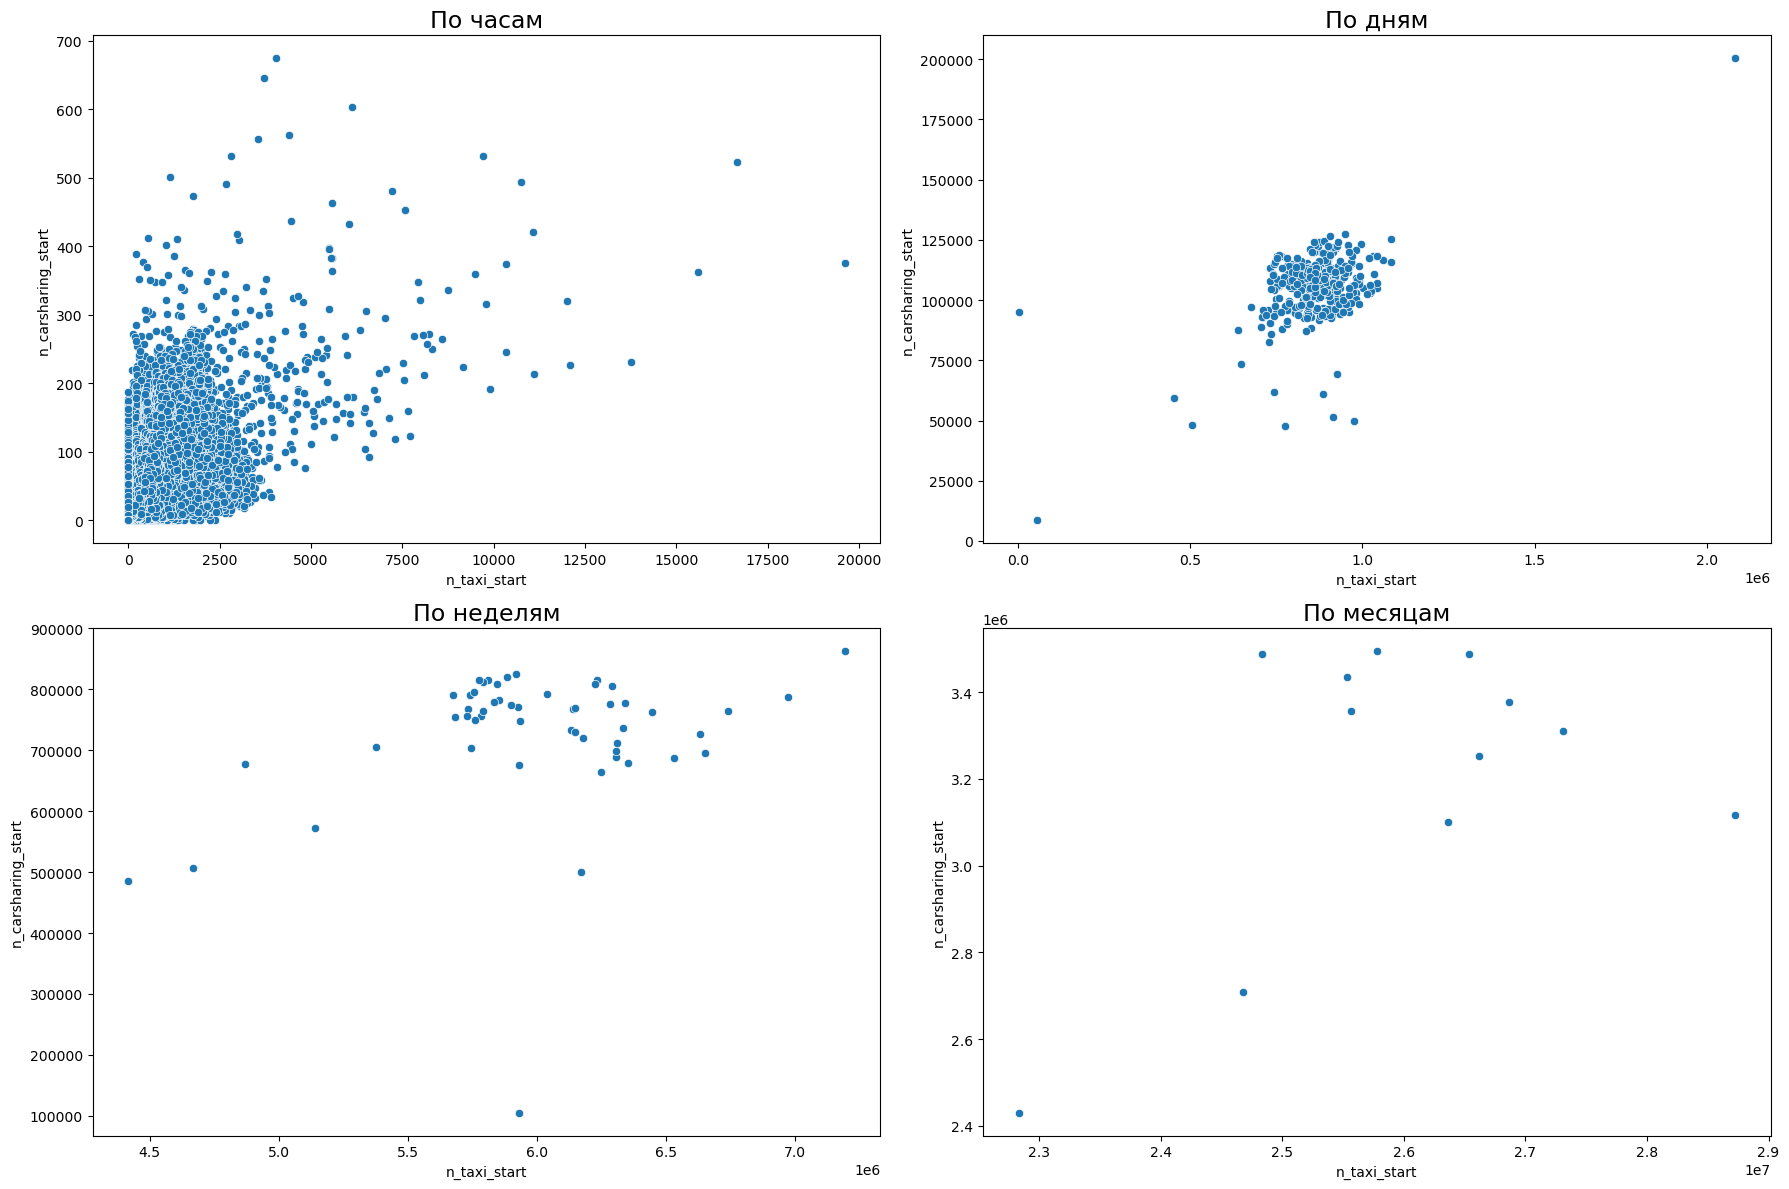

In [166]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(18, 12))

# По часам
plt.subplot(2, 2, 1)
sns.scatterplot(x='n_taxi_start', y='n_carsharing_start', data=df_research)
plt.title('По часам', fontsize=17)

# По дням
plt.subplot(2, 2, 2)
sns.scatterplot(x='n_taxi_start', y='n_carsharing_start', data=df_daily)
plt.title('По дням', fontsize=17)

# По неделям
plt.subplot(2, 2, 3)
sns.scatterplot(x='n_taxi_start', y='n_carsharing_start', data=df_weekly)
plt.title('По неделям', fontsize=17)

# По месяцам
plt.subplot(2, 2, 4)
sns.scatterplot(x='n_taxi_start', y='n_carsharing_start', data=df_monthly)
plt.title('По месяцам', fontsize=17)

plt.tight_layout()
plt.show()

## 6. Постройте матрицу корреляций числовых переменных.

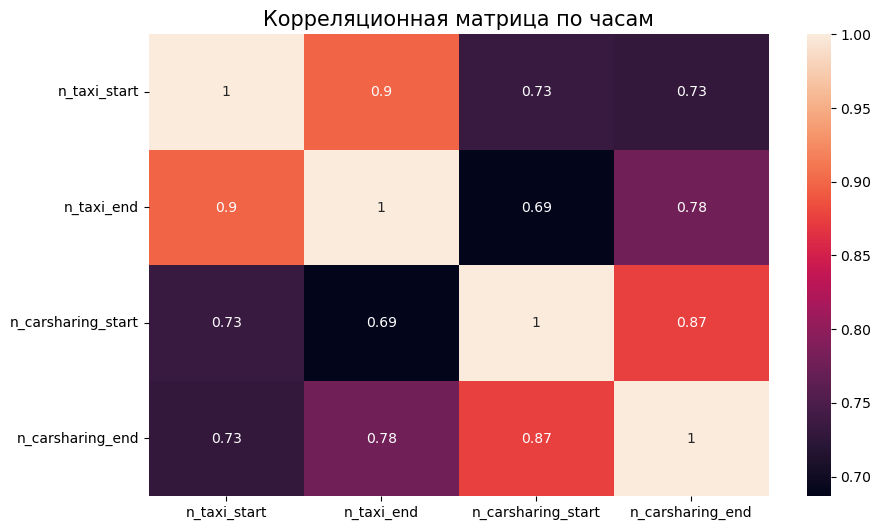

In [170]:
fig, ax = plt.subplots(figsize=(10, 6))
ax = sns.heatmap(data=df_research[['n_taxi_start','n_taxi_end', 'n_carsharing_start', 'n_carsharing_end']].corr(), ax=ax , annot=True)
ax.set_title('Корреляционная матрица по часам', fontsize=15);

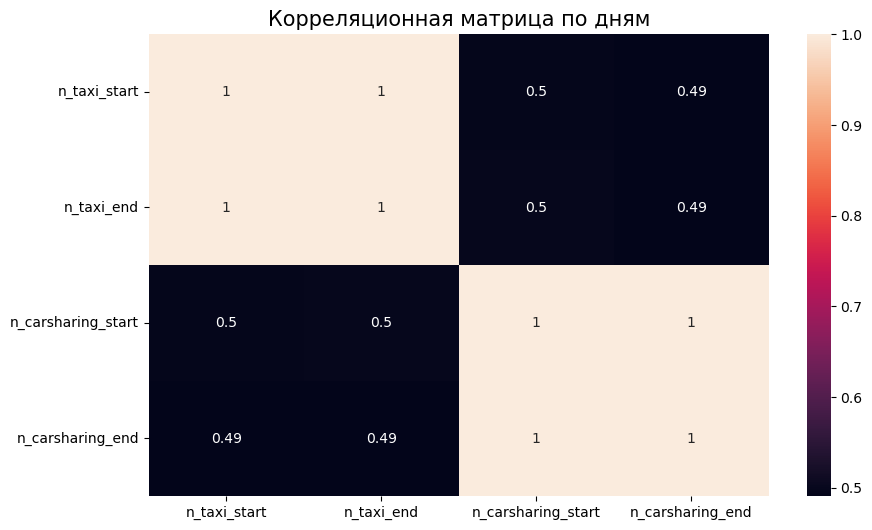

In [172]:
fig, ax = plt.subplots(figsize=(10, 6))
ax = sns.heatmap(data=df_daily[['n_taxi_start','n_taxi_end', 'n_carsharing_start', 'n_carsharing_end']].corr(), ax=ax , annot=True)
ax.set_title('Корреляционная матрица по дням', fontsize=15);

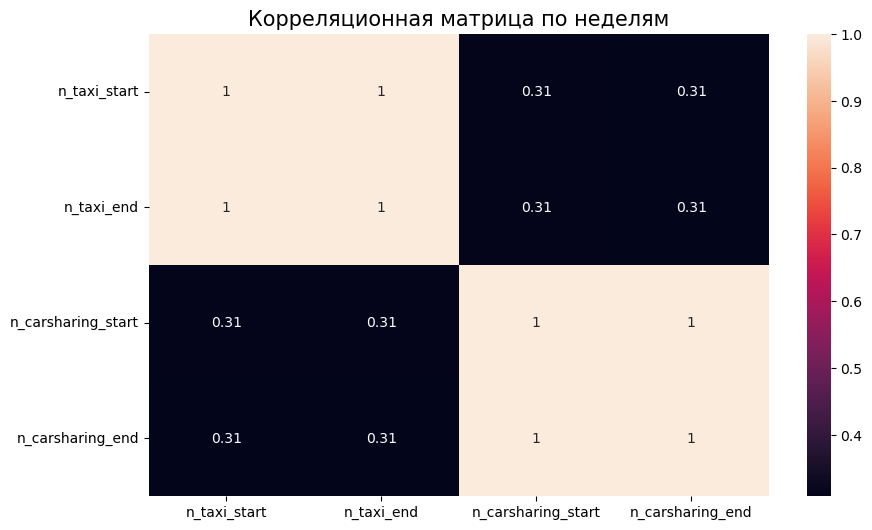

In [174]:
fig, ax = plt.subplots(figsize=(10, 6))
ax = sns.heatmap(data=df_weekly[['n_taxi_start','n_taxi_end', 'n_carsharing_start', 'n_carsharing_end']].corr(), ax=ax , annot=True)
ax.set_title('Корреляционная матрица по неделям', fontsize=15);

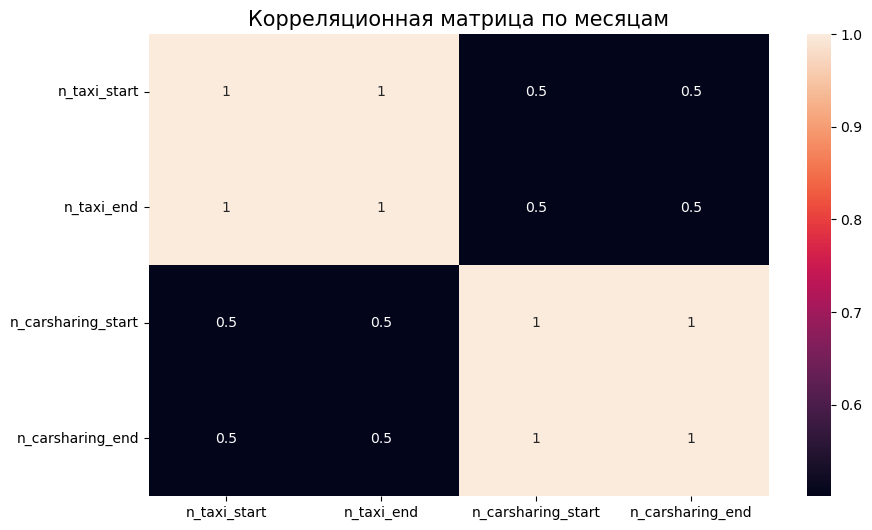

In [176]:
fig, ax = plt.subplots(figsize=(10, 6))
ax = sns.heatmap(data=df_monthly[['n_taxi_start','n_taxi_end', 'n_carsharing_start', 'n_carsharing_end']].corr(), ax=ax , annot=True)
ax.set_title('Корреляционная матрица по месяцам', fontsize=15);

Мы наблюдаем сильную положительную корреляцию между признаками поездок в такси и каршеринге

## 7. Визуализируйте данные (например, с помощью matplotlib и seaborn).

постройте гистограммы распределения числовых переменных

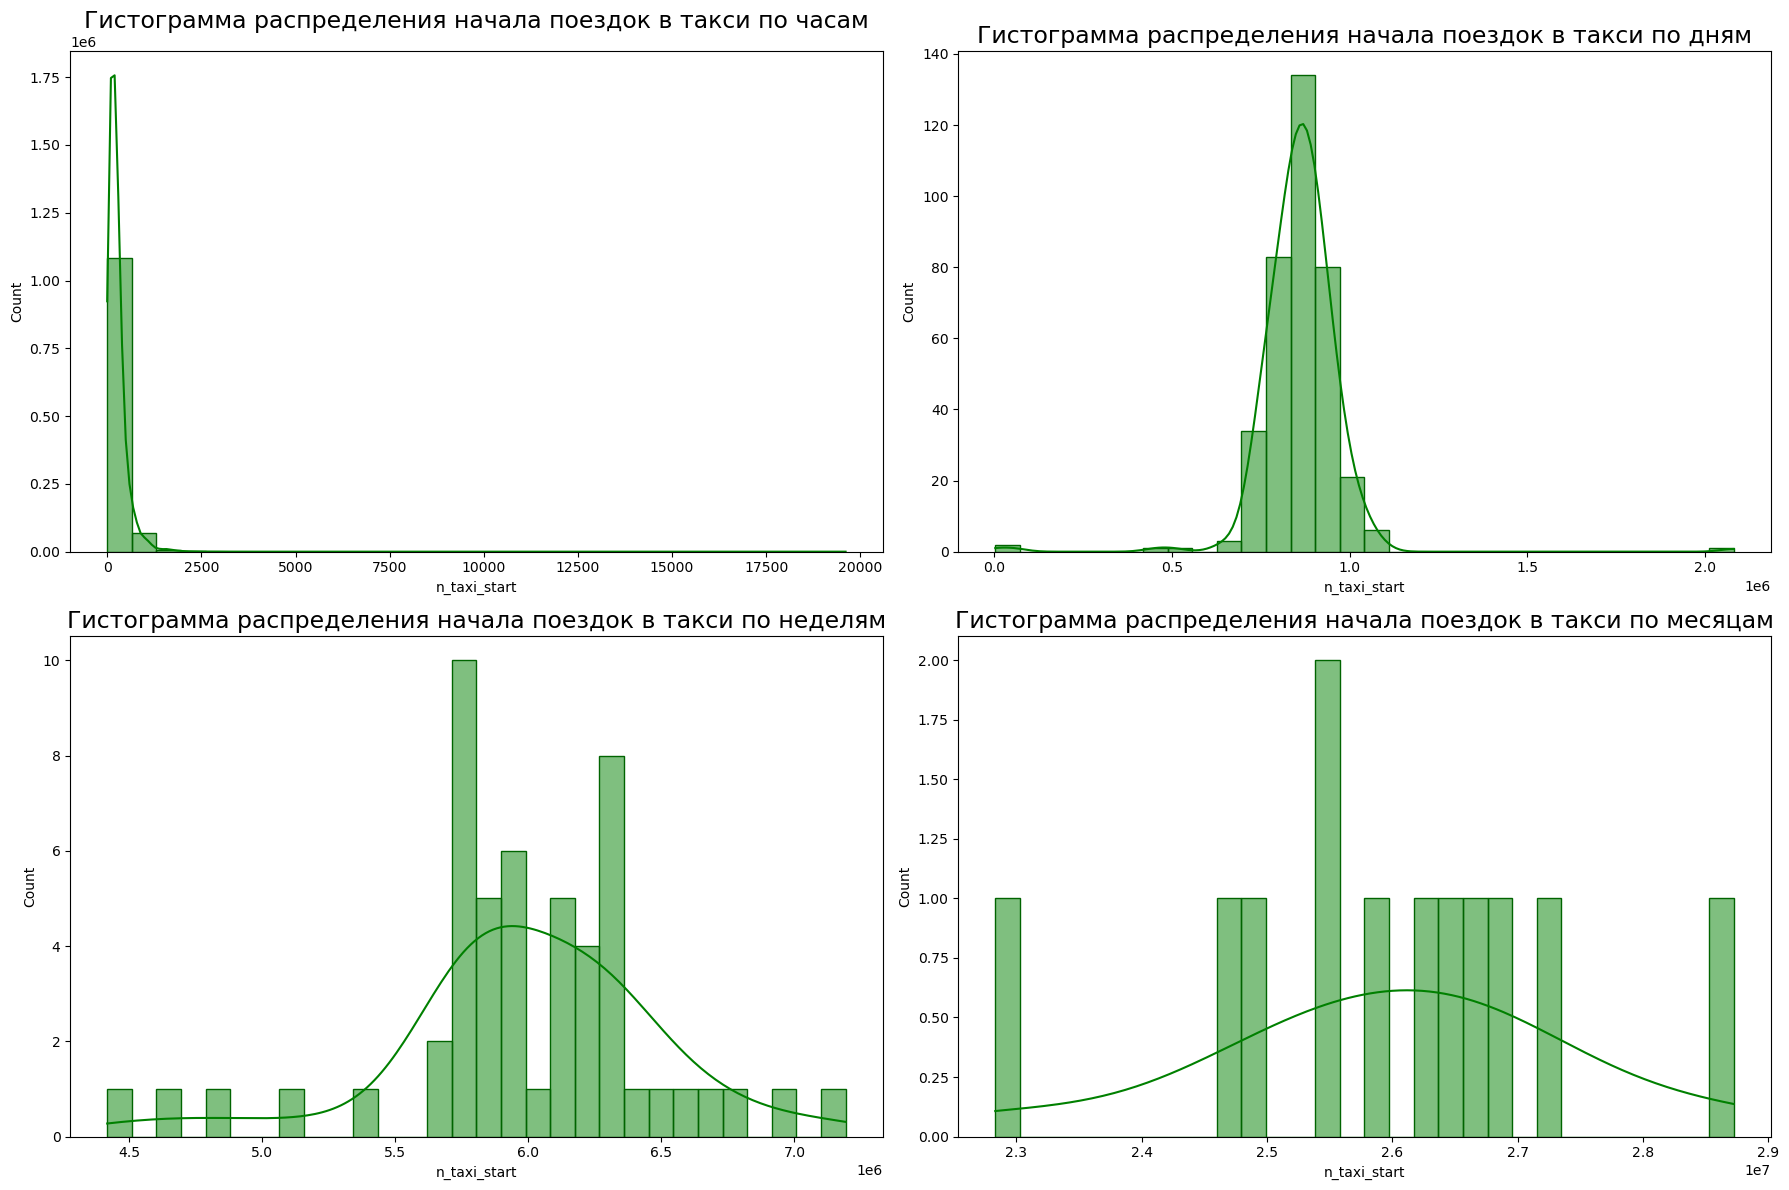

In [180]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(18, 12))

plt.subplot(2, 2, 1)
sns.histplot(df_research.n_taxi_start, bins=30, color='green', edgecolor='darkgreen', kde=True)
plt.title('Гистограмма распределения начала поездок в такси по часам', fontsize=17)

plt.subplot(2, 2, 2)
sns.histplot(df_daily.n_taxi_start, bins=30, color='green', edgecolor='darkgreen', kde=True)
plt.title('Гистограмма распределения начала поездок в такси по дням', fontsize=17)

plt.subplot(2, 2, 3)
sns.histplot(df_weekly.n_taxi_start, bins=30, color='green', edgecolor='darkgreen', kde=True)
plt.title('Гистограмма распределения начала поездок в такси по неделям', fontsize=17)

plt.subplot(2, 2, 4)
sns.histplot(df_monthly.n_taxi_start, bins=30, color='green', edgecolor='darkgreen', kde=True)
plt.title('Гистограмма распределения начала поездок в такси по месяцам', fontsize=17)

plt.tight_layout()
plt.show()


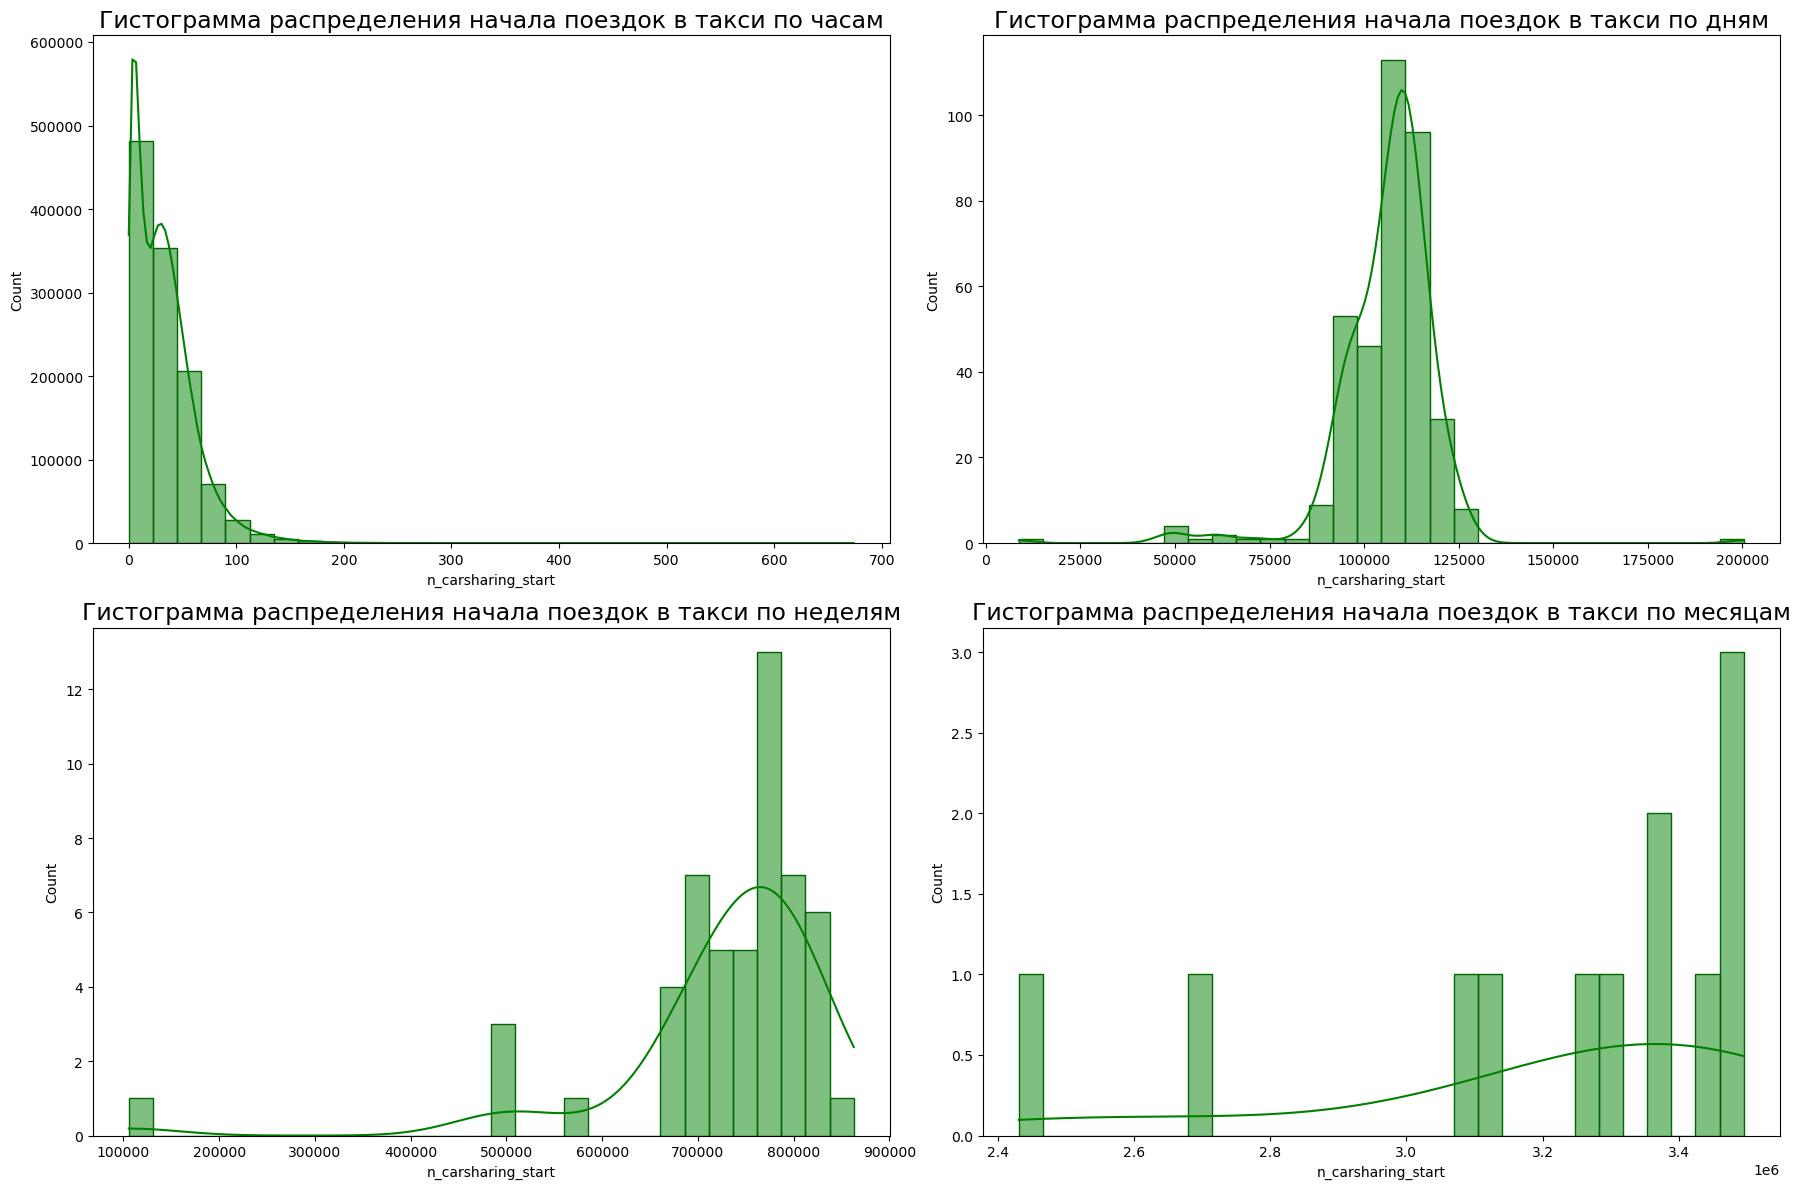

In [186]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(18, 12))

plt.subplot(2, 2, 1)
sns.histplot(df_research.n_carsharing_start, bins=30, color='green', edgecolor='darkgreen', kde=True)
plt.title('Гистограмма распределения начала поездок в такси по часам', fontsize=17)

plt.subplot(2, 2, 2)
sns.histplot(df_daily.n_carsharing_start, bins=30, color='green', edgecolor='darkgreen', kde=True)
plt.title('Гистограмма распределения начала поездок в такси по дням', fontsize=17)

plt.subplot(2, 2, 3)
sns.histplot(df_weekly.n_carsharing_start, bins=30, color='green', edgecolor='darkgreen', kde=True)
plt.title('Гистограмма распределения начала поездок в такси по неделям', fontsize=17)

plt.subplot(2, 2, 4)
sns.histplot(df_monthly.n_carsharing_start, bins=30, color='green', edgecolor='darkgreen', kde=True)
plt.title('Гистограмма распределения начала поездок в такси по месяцам', fontsize=17)

plt.tight_layout()
plt.show()


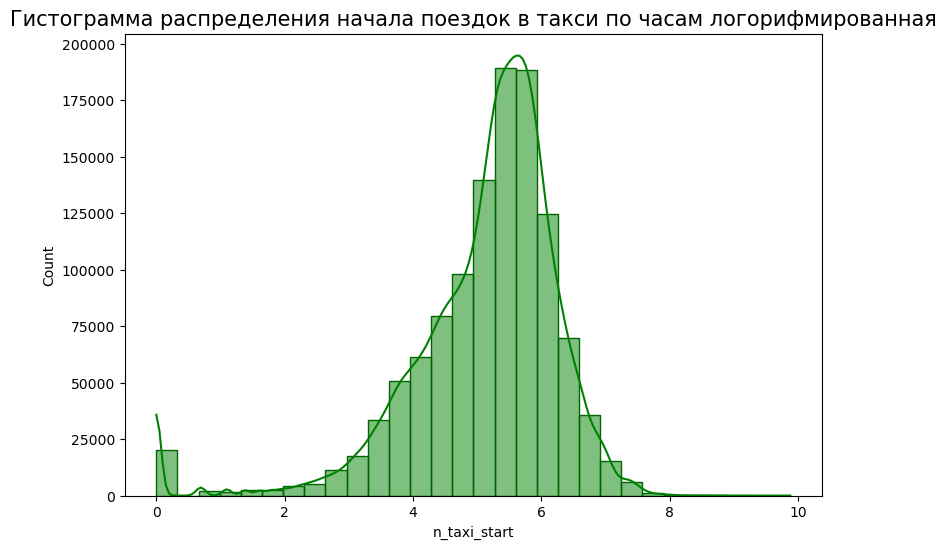

In [184]:
fig, ax = plt.subplots(figsize=(9, 6))
ax.set_title('Гистограмма распределения начала поездок в такси по часам логорифмированная', fontsize=15)
sns.histplot(np.log1p(df_research.n_taxi_start),
             bins=30,
             ax=ax,
             color='green',
             edgecolor='darkgreen',
             kde=True
            );

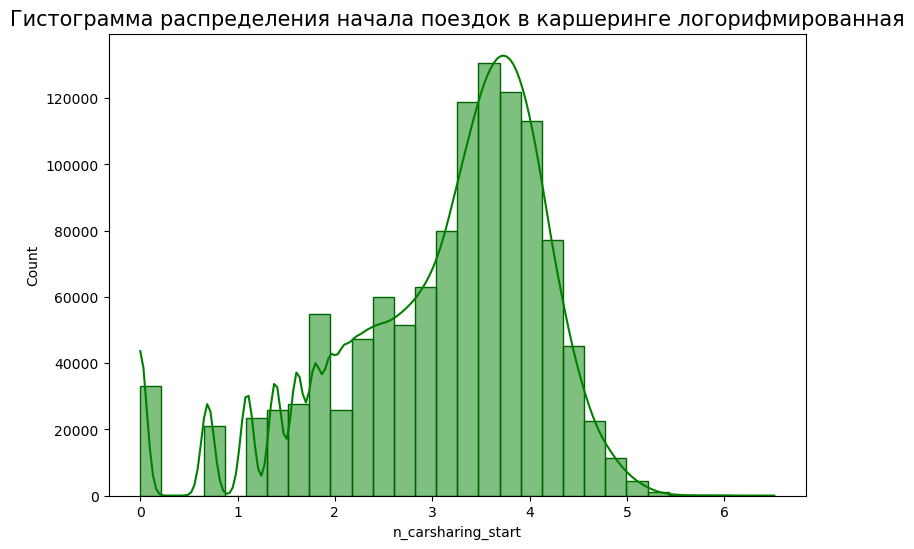

In [190]:
fig, ax = plt.subplots(figsize=(9, 6))
ax.set_title('Гистограмма распределения начала поездок в каршеринге логорифмированная', fontsize=15)
sns.histplot(np.log1p(df_research.n_carsharing_start),
             bins=30,
             ax=ax,
             color='green',
             edgecolor='darkgreen',
             kde=True
            );

проверьте попарные связи переменных друг с другом (например, с помощью scatterplot) и с целевой переменной

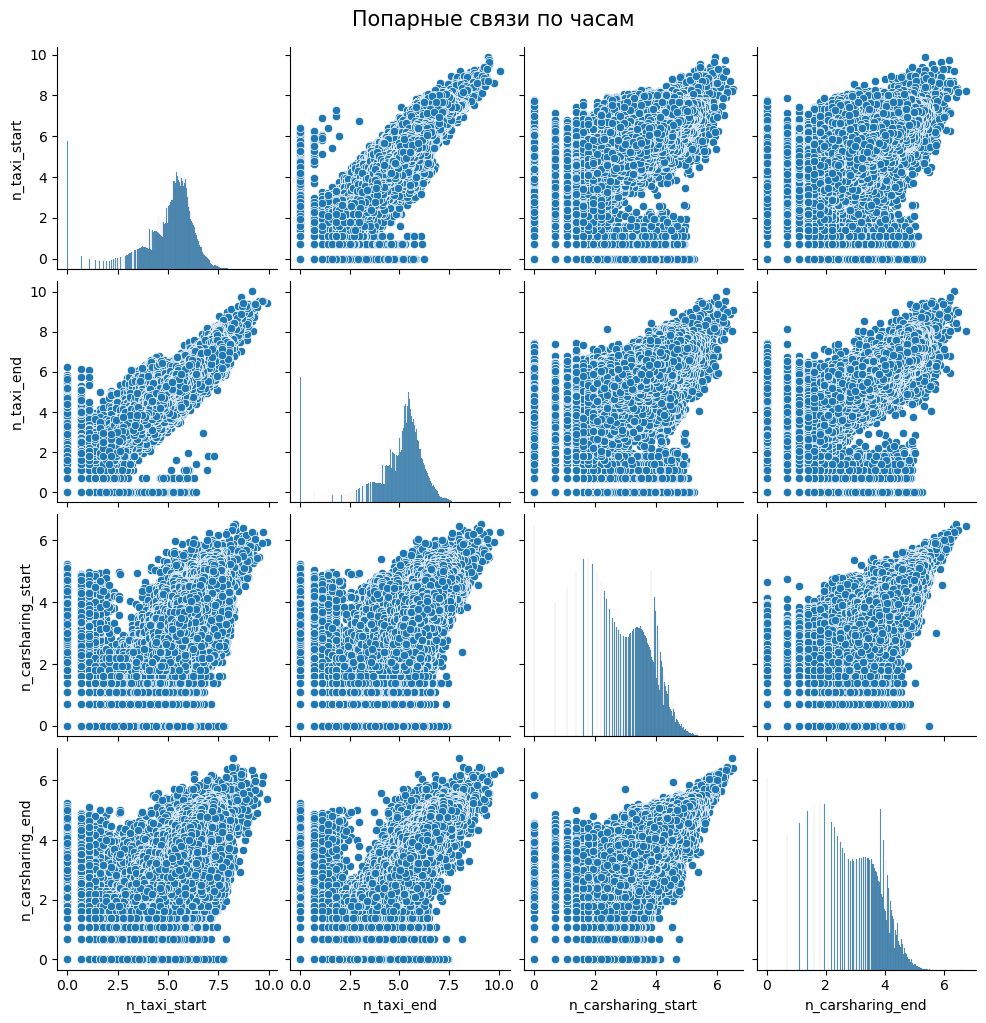

In [204]:
sns.pairplot(np.log1p(df_research[['n_taxi_start','n_taxi_end', 'n_carsharing_start', 'n_carsharing_end']]))
plt.suptitle('Попарные связи по часам', fontsize=15, y=1.02)
plt.show()

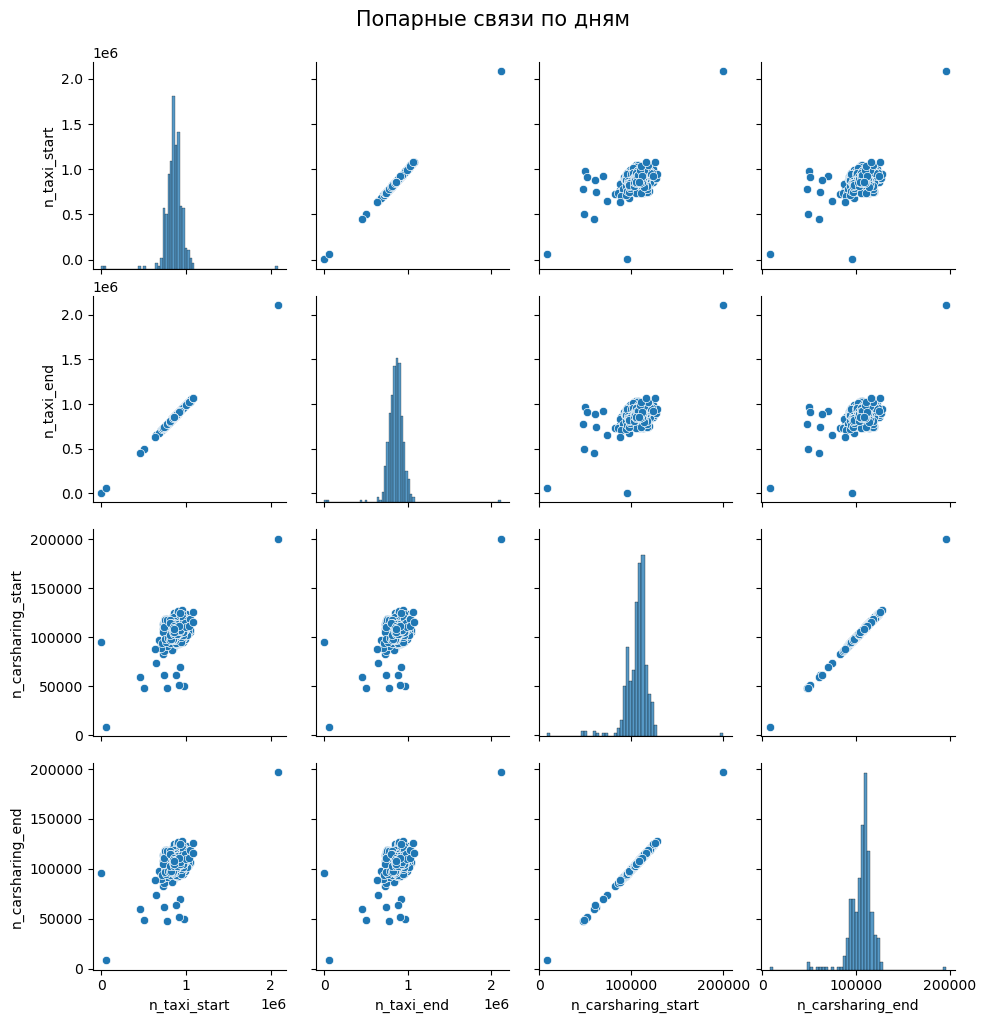

In [206]:
sns.pairplot(df_daily[['n_taxi_start','n_taxi_end', 'n_carsharing_start', 'n_carsharing_end']])
plt.suptitle('Попарные связи по дням', fontsize=15, y=1.02)
plt.show()

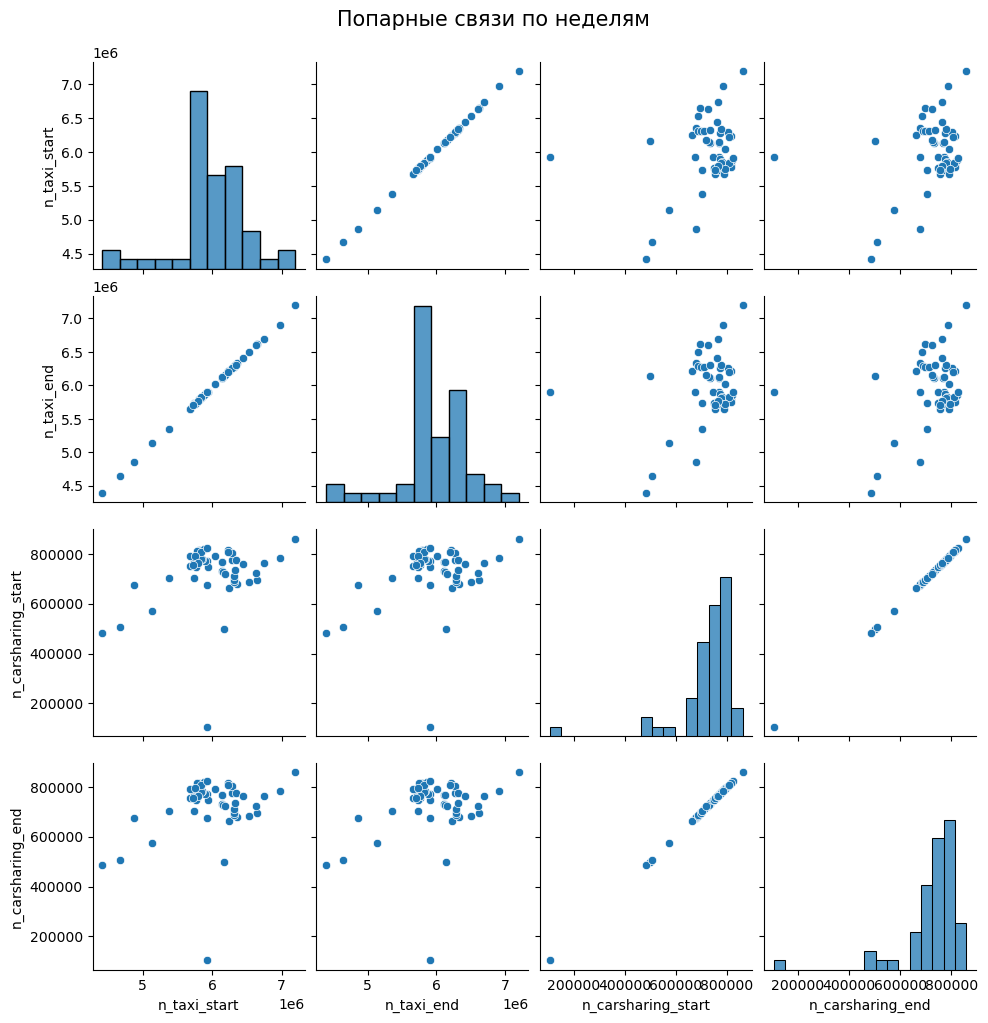

In [208]:
sns.pairplot(df_weekly[['n_taxi_start','n_taxi_end', 'n_carsharing_start', 'n_carsharing_end']]);
plt.suptitle('Попарные связи по неделям', fontsize=15, y=1.02)
plt.show()

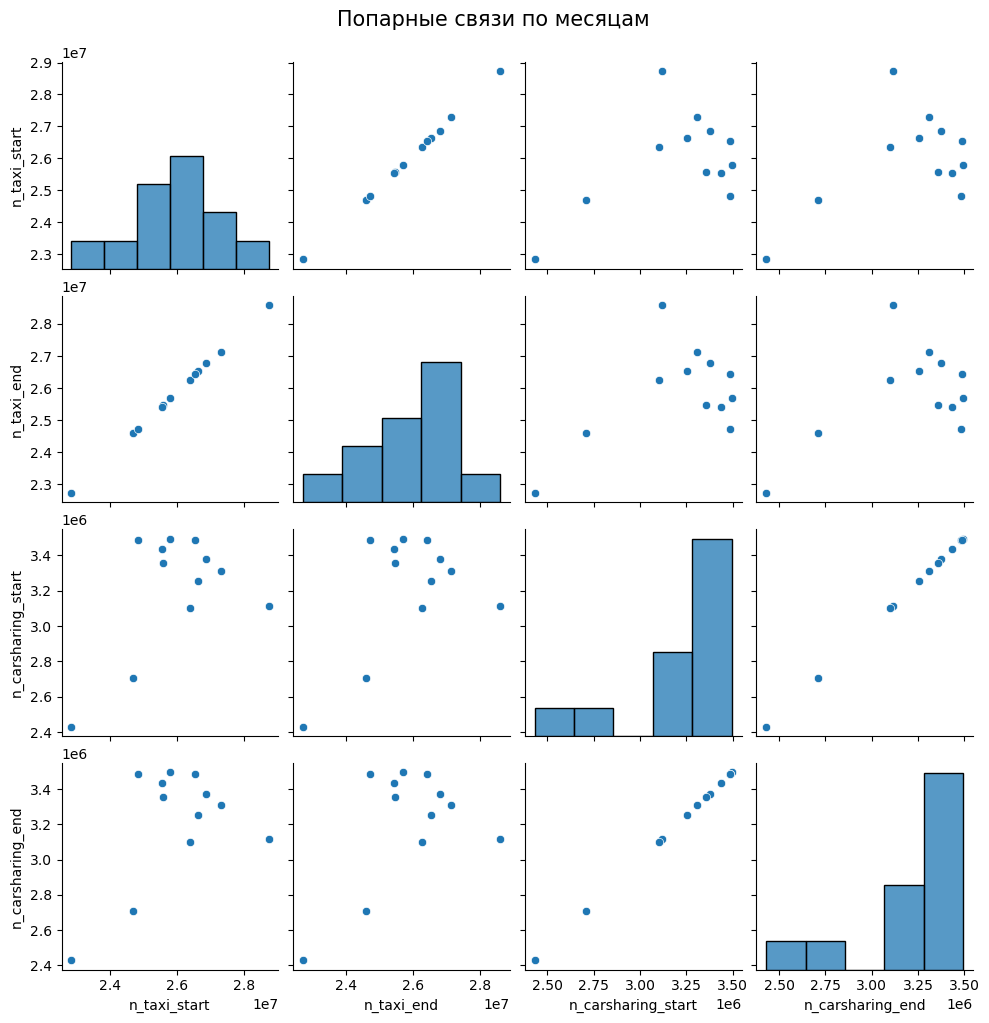

In [210]:
sns.pairplot(df_monthly[['n_taxi_start','n_taxi_end', 'n_carsharing_start', 'n_carsharing_end']])
plt.suptitle('Попарные связи по месяцам', fontsize=15, y=1.02)
plt.show()

**Мой вывод:**

В большинстве распределений имеем восходящее линейное распределение, тоесть имеем положительную корреляцию между данными признаками

## 8. По возможности попробуйте задать какие-нибудь вопросы и ответить на них, используя ваши данные. Постройте необходимые сводные таблицы и графики.

Интересно было бы узнать совпадает ли распределение спроса на такси и каршеринг по районам москвы, а также узнать в какие месяцы больше популярно такси, а в какие каршеринг

In [213]:
def get_plot(df, column_name, title):
    df_draw = df.groupby(['district_name'])[column_name] \
                .sum() \
                .sort_values(ascending=False) \
                .head(5)
    
    plt.pie(df_draw, 
            labels=df_draw.index, 
            autopct='%1.1f%%', 
            colors=sns.color_palette('pastel')[0:5],
            textprops={'family': 'monospace'}, 
            startangle=90)
    
    plt.title(title, fontweight='bold', family='monospace')

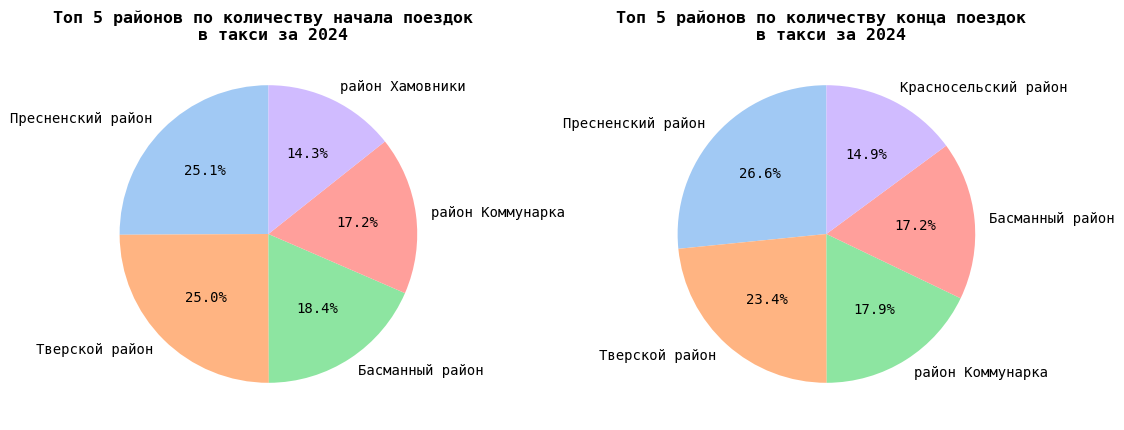

In [215]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
fig.subplots_adjust(wspace=0.5)

plt.sca(axes[0])
get_plot(df_research, 'n_taxi_start', 'Топ 5 районов по количеству начала поездок \n в такси за 2024')

plt.sca(axes[1])
get_plot(df_research, 'n_taxi_end', 'Топ 5 районов по количеству конца поездок \n в такси за 2024')

plt.show()

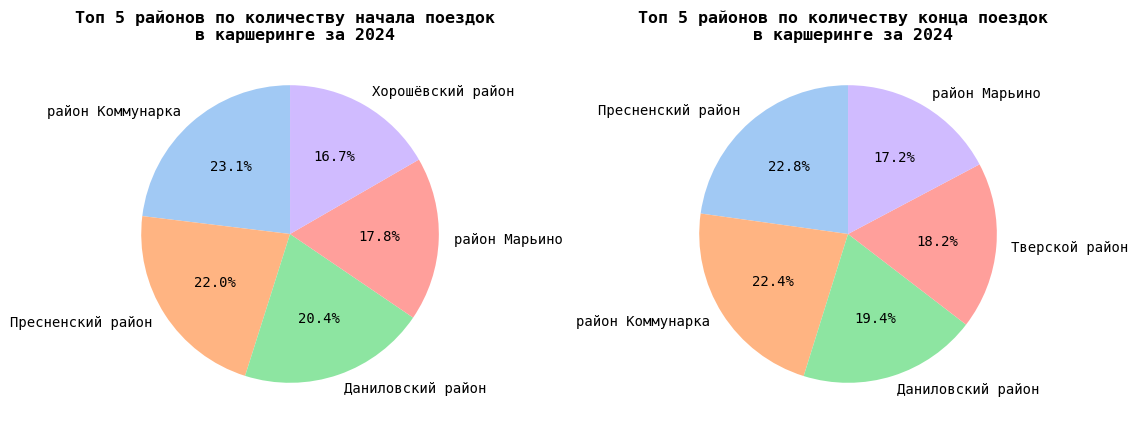

In [217]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
fig.subplots_adjust(wspace=0.5)

plt.sca(axes[0])
get_plot(df_research, 'n_carsharing_start', 'Топ 5 районов по количеству начала поездок \n в каршеринге за 2024')

plt.sca(axes[1])
get_plot(df_research, 'n_carsharing_end', 'Топ 5 районов по количеству конца поездок \n в каршеринге за 2024')

plt.show()

Мы можем видеть разницу в районах: люди чаще выезжают из коммунарки, думаю это связано с тем, что добираться из данного региона долго и когда жители утром опаздывают на работу, они чаще берут каршеринг, тогда как в вечернее время, когда добираются домой, могут позволить себе более экономный - общественный вид транспорта

In [238]:
def calmap(cal_data, title, metric, scale):
    
    cal_data['date'] = pd.to_datetime(cal_data['timestamp'])
    cal_data['year'] = cal_data['date'].dt.year
    cal_data['week'] = cal_data['date'].dt.isocalendar().week
    cal_data['day_name'] = cal_data['date'].dt.strftime('%A')
    
    years = cal_data['year'].unique().tolist()

    fig = make_subplots(rows=len(years), cols=1, shared_xaxes=True, vertical_spacing=0.005)
    
    row = 1
    for year in years:
        data = cal_data[cal_data['year'] == year]
        
        fig.add_trace(go.Heatmap(
            z=data[metric],
            x=data['week'],
            y=data['day_name'],
            hovertext=data['date'].dt.date,
            coloraxis="coloraxis", 
            name=str(year)
        ), row, 1)
        
        fig.update_yaxes(title_text=str(year), tickfont=dict(size=8), row=row, col=1)
        row += 1
    
    fig.update_xaxes(range=[1, 53], tickfont=dict(size=10), nticks=53)
    fig.update_layout(coloraxis={'colorscale': scale})
    fig.update_layout(template='seaborn', title=title)
    
    return fig

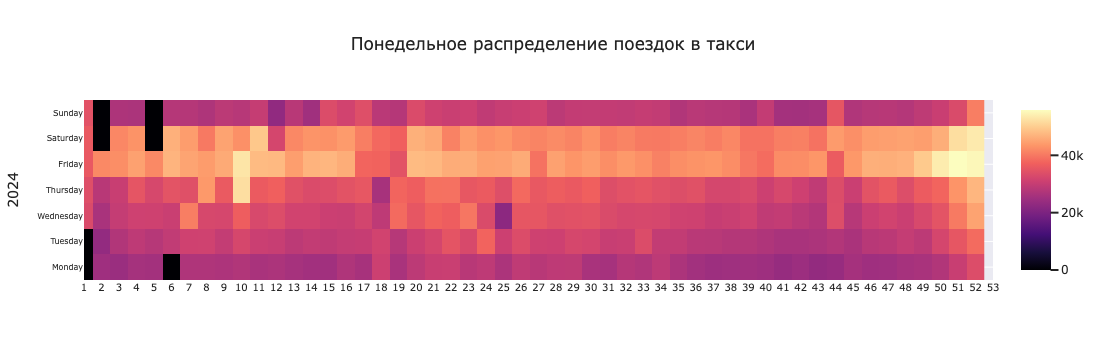

In [240]:
calmap(df_research.groupby(['timestamp'], as_index=False).n_taxi_start.sum(), 
       title='Понедельное распределение поездок в такси', 
       metric='n_taxi_start', 
       scale='magma')

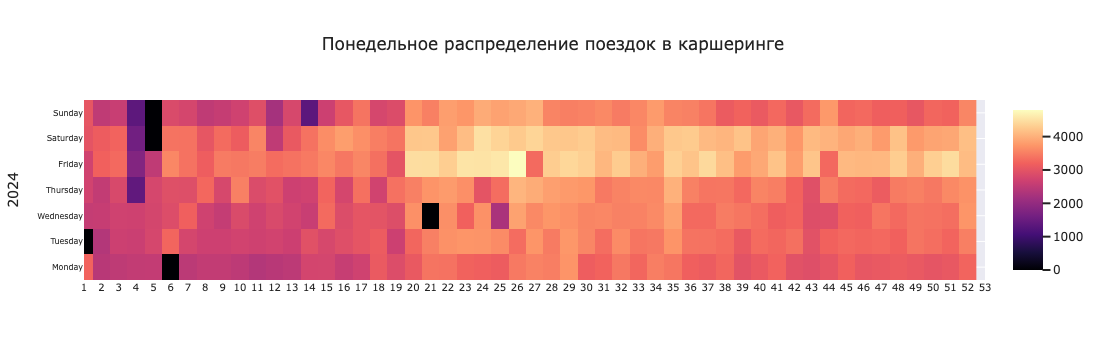

In [242]:
calmap(df_research.groupby(['timestamp'], as_index=False).n_carsharing_start.sum(), 
       title='Понедельное распределение поездок в каршеринге', 
       metric='n_carsharing_start', 
       scale='magma')

In [219]:
df_research['month_name'] = df_research['timestamp'].dt.strftime('%B')

In [220]:
df_research['month_name'] = df_research['timestamp'].dt.strftime('%B').map({
    'January': 'Январь', 'February': 'Февраль', 'March': 'Март',
    'April': 'Апрель', 'May': 'Май', 'June': 'Июнь',
    'July': 'Июль', 'August': 'Август', 'September': 'Сентябрь',
    'October': 'Октябрь', 'November': 'Ноябрь', 'December': 'Декабрь'
})


In [223]:
df_draw_taxi = df_research.groupby('month_name').agg({'n_taxi_start': 'sum',
                                                 'timestamp': 'min'}) \
        .sort_values(by='timestamp')


In [225]:
df_draw_carsharing  = df_research.groupby('month_name').agg({'n_carsharing_start': 'sum',
                                                 'timestamp': 'min'}) \
        .sort_values(by='timestamp')

In [227]:
df_draw_carsharing

,n_carsharing_start,timestamp
month_name,,
Январь,2708394,2024-01-01
Февраль,2430919,2024-02-01
Март,3116449,2024-03-01
Апрель,3101246,2024-04-01
Май,3253541,2024-05-01
Июнь,3377702,2024-06-01
Июль,3357462,2024-07-01
Август,3495125,2024-08-01
Сентябрь,3487123,2024-09-01


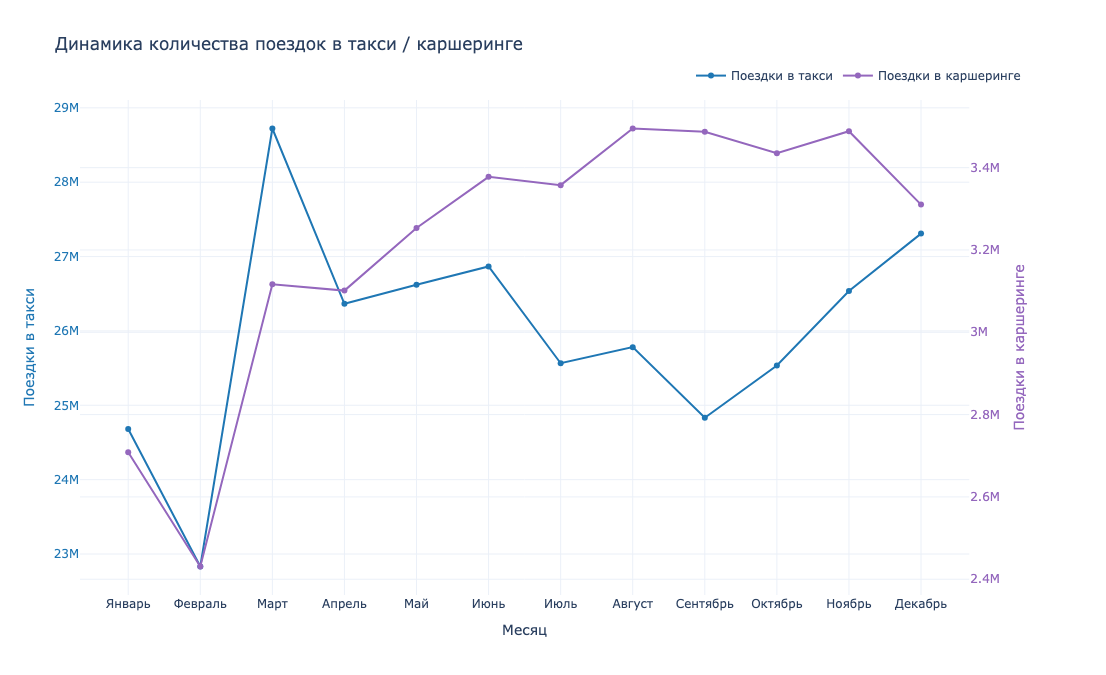

In [229]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots


fig = make_subplots(specs=[[{"secondary_y": True}]])

fig.add_trace(
    go.Scatter(
        x=df_draw_taxi.index,
        y=df_draw_taxi.n_taxi_start,
        name="Поездки в такси",
        line=dict(color='#1f77b4'),
    ),
    secondary_y=False
)

fig.add_trace(
    go.Scatter(
        x=df_draw_carsharing.index,
        y=df_draw_carsharing.n_carsharing_start,
        name="Поездки в каршеринге",
        line=dict(color='#9467bd'),
    ),
    secondary_y=True
)

fig.update_layout(
    title_text="Динамика количества поездок в такси / каршеринге",
    width=1100,
    height=675,
    template='plotly_white',
    hovermode='x unified',
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1)
)

fig.update_yaxes(
    title_text="Поездки в такси",
    title_font=dict(color='#1f77b4'),
    tickfont=dict(color='#1f77b4'),
    secondary_y=False
)

fig.update_yaxes(
    title_text="Поездки в каршеринге",
    title_font=dict(color='#9467bd'),
    tickfont=dict(color='#9467bd'),
    secondary_y=True
)

fig.update_xaxes(title_text="Месяц")

fig.show()

## 9. Сделайте развернутые выводы.

Несмотря на то, что данные собирались с официального сайта, благодаря анализу удалось обнаружить пропуски в данных в праздничные дни. Грамотно обработать данные. Поскольку мы работали с временными данными, то имеет смысл группировать данные по разным временным интервалам. Тем не менее, я считаю, для дальнейшего анализа было бы более разумным использовать соответсвующие линейные графики для оценки динамики и разброса, поскольку наша основная задача предсказать показатели поездок в такси и каршеринге на некоторый срок вперед.
Те признаки по которым я производил свой анализ коррелируют линейно положительно, что логично поскольку при росте спроса на такси растет спрос и на каршеринг как альтернативное транспортное средство.
Кроме того, в финальном графике, я заметил повышенный спрос с началом весны и до конца лета на каршеринг, тогда как такси имеет нисходящую динамику которая меняется на противоположную для такси и каршеринга в сентябре 2024 года.